# Pipeline

## Data Loading and EDA

This section loads the relational tennis tables into DuckDB, prepares a modeling dataset with SQL, and performs brief exploratory data analysis.

In [3]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import logging
import numpy as np

# Configuring logging
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Exact project paths
PROJECT_ROOT = Path("/Users/dylandietrich/Documents/New project")
EXPORTS_DIR = PROJECT_ROOT / "data" / "exports"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("EXPORTS_DIR =", EXPORTS_DIR)
print("players.csv exists:", (EXPORTS_DIR / "players.csv").exists())

PROJECT_ROOT = /Users/dylandietrich/Documents/New project
EXPORTS_DIR = /Users/dylandietrich/Documents/New project/data/exports
players.csv exists: True


In [4]:
csv_tables = {
    "players": EXPORTS_DIR / "players.csv",
    "player_rankings": EXPORTS_DIR / "player_rankings.csv",
    "player_utr_ratings": EXPORTS_DIR / "player_utr_ratings.csv",
    "player_aliases": EXPORTS_DIR / "player_aliases.csv",
    "tournaments": EXPORTS_DIR / "tournaments.csv",
    "tournament_editions": EXPORTS_DIR / "tournament_editions.csv",
    "matches": EXPORTS_DIR / "matches.csv",
    "player_match_stats": EXPORTS_DIR / "player_match_stats.csv",
    "player_match_load_features": EXPORTS_DIR / "player_match_load_features.csv",
    "point_events": EXPORTS_DIR / "point_events.csv",
}

con = duckdb.connect()

for table_name, file_path in csv_tables.items():
    safe_path = str(file_path).replace("\\", "/")
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT *
        FROM read_csv_auto('{safe_path}', HEADER=TRUE, SAMPLE_SIZE=-1);
    """)
    logging.info(f"Loaded {table_name}")
    print(f"Loaded {table_name} from {file_path.name}")

Loaded players from players.csv
Loaded player_rankings from player_rankings.csv
Loaded player_utr_ratings from player_utr_ratings.csv
Loaded player_aliases from player_aliases.csv
Loaded tournaments from tournaments.csv
Loaded tournament_editions from tournament_editions.csv
Loaded matches from matches.csv
Loaded player_match_stats from player_match_stats.csv
Loaded player_match_load_features from player_match_load_features.csv
Loaded point_events from point_events.csv


In [5]:
row_counts = con.execute("""
    SELECT 'players' AS table_name, COUNT(*) AS n FROM players
    UNION ALL
    SELECT 'player_rankings', COUNT(*) FROM player_rankings
    UNION ALL
    SELECT 'tournament_editions', COUNT(*) FROM tournament_editions
    UNION ALL
    SELECT 'matches', COUNT(*) FROM matches
    UNION ALL
    SELECT 'player_match_stats', COUNT(*) FROM player_match_stats
    UNION ALL
    SELECT 'player_match_load_features', COUNT(*) FROM player_match_load_features
    ORDER BY table_name;
""").fetchdf()

row_counts

,table_name,n
0,matches,198077
1,player_match_load_features,396148
2,player_match_stats,396151
3,player_rankings,3292228
4,players,65989
5,tournament_editions,8665


In [6]:
model_sql = """
WITH base AS (
    SELECT
        CAST(s.match_id AS VARCHAR) AS match_id,
        CAST(s.player_id AS VARCHAR) AS player_id,
        CAST(s.opponent_id AS VARCHAR) AS opponent_id,
        CAST(s.is_winner AS INTEGER) AS target,
        CAST(m.start_time_utc AS DATE) AS match_date,
        m.surface,
        m.best_of,
        m.tourney_level,
        l.player_minutes_last_7d,
        l.player_matches_last_7d,
        l.opponent_minutes_last_7d,
        l.opponent_matches_last_7d,
        l.minutes_diff_last_7d
    FROM player_match_stats s
    JOIN matches m
      ON CAST(m.match_id AS VARCHAR) = CAST(s.match_id AS VARCHAR)
    LEFT JOIN player_match_load_features l
      ON CAST(l.match_id AS VARCHAR) = CAST(s.match_id AS VARCHAR)
     AND CAST(l.player_id AS VARCHAR) = CAST(s.player_id AS VARCHAR)
)
SELECT
    b.*,
    (
        SELECT pr.rank
        FROM player_rankings pr
        WHERE CAST(pr.player_id AS VARCHAR) = b.player_id
          AND CAST(pr.ranking_date AS DATE) <= b.match_date
        ORDER BY CAST(pr.ranking_date AS DATE) DESC
        LIMIT 1
    ) AS player_rank,
    (
        SELECT pr.points
        FROM player_rankings pr
        WHERE CAST(pr.player_id AS VARCHAR) = b.player_id
          AND CAST(pr.ranking_date AS DATE) <= b.match_date
        ORDER BY CAST(pr.ranking_date AS DATE) DESC
        LIMIT 1
    ) AS player_points,
    (
        SELECT pr.rank
        FROM player_rankings pr
        WHERE CAST(pr.player_id AS VARCHAR) = b.opponent_id
          AND CAST(pr.ranking_date AS DATE) <= b.match_date
        ORDER BY CAST(pr.ranking_date AS DATE) DESC
        LIMIT 1
    ) AS opponent_rank,
    (
        SELECT pr.points
        FROM player_rankings pr
        WHERE CAST(pr.player_id AS VARCHAR) = b.opponent_id
          AND CAST(pr.ranking_date AS DATE) <= b.match_date
        ORDER BY CAST(pr.ranking_date AS DATE) DESC
        LIMIT 1
    ) AS opponent_points
FROM base b
WHERE b.target IS NOT NULL;
"""

df = con.execute(model_sql).fetchdf()

print("Shape:", df.shape)
print("\nMissing values:\n")
print(df.isnull().sum())
df.head()

Shape: (396151, 17)

Missing values:

match_id                         0
player_id                        0
opponent_id                      0
target                           0
match_date                       0
surface                       5980
best_of                          0
tourney_level                    0
player_minutes_last_7d           3
player_matches_last_7d           3
opponent_minutes_last_7d         3
opponent_matches_last_7d         3
minutes_diff_last_7d             3
player_rank                  56361
player_points               181835
opponent_rank                56361
opponent_points             181835
dtype: int64


,match_id,player_id,opponent_id,target,match_date,surface,best_of,tourney_level,player_minutes_last_7d,player_matches_last_7d,opponent_minutes_last_7d,opponent_matches_last_7d,minutes_diff_last_7d,player_rank,player_points,opponent_rank,opponent_points
0,2023-9410|2023-09-25|298|SF|105173|124116,105173,124116,1,2023-09-24,Hard,3,A,359,3,327,3,32,34,1286,59,885
1,2023-9410|2023-09-25|298|SF|105173|124116,124116,105173,0,2023-09-24,Hard,3,A,327,3,359,3,-32,59,885,34,1286
2,2023-9410|2023-09-25|299|SF|200624|209098,200624,209098,1,2023-09-24,Hard,3,A,655,6,191,3,464,33,1295,120,503
3,2023-9410|2023-09-25|299|SF|200624|209098,209098,200624,0,2023-09-24,Hard,3,A,191,3,655,6,-464,120,503,33,1295
4,2023-9410|2023-09-25|300|F|105173|200624,105173,200624,1,2023-09-24,Hard,3,A,429,4,827,7,-398,34,1286,33,1295


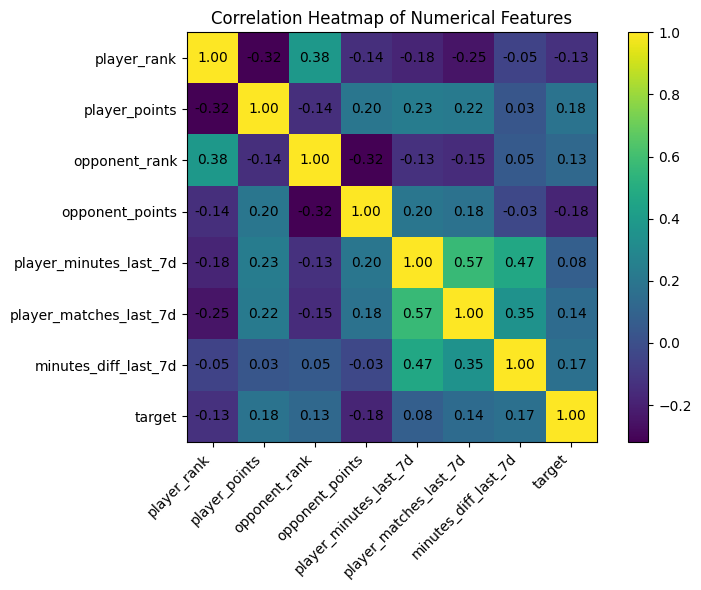

In [7]:
eda_cols = [
    "player_rank",
    "player_points",
    "opponent_rank",
    "opponent_points",
    "player_minutes_last_7d",
    "player_matches_last_7d",
    "minutes_diff_last_7d",
    "target"
]

corr = df[eda_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap of Numerical Features")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Analysis Rationale

I used DuckDB because this project is built from multiple relational tennis tables that are naturally combined with SQL. I created the modeling dataset by joining player-level match records with pre-match ranking information and recent workload features such as minutes played and matches played in the last 7 days.

I used logistic regression as a simple and interpretable baseline model from DS 3021/4021. This model is appropriate because the target is binary (`is_winner`), and it produces probabilities that can be evaluated with ROC AUC in addition to accuracy. I included both player and opponent features, as well as relative strength features such as ranking gap and points gap, because match outcomes depend on the difference in strength between players rather than on one player’s values alone.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, RocCurveDisplay

df["rank_gap"] = df["opponent_rank"] - df["player_rank"]
df["points_gap"] = df["player_points"] - df["opponent_points"]

feature_cols = [
    "player_rank",
    "player_points",
    "opponent_rank",
    "opponent_points",
    "rank_gap",
    "points_gap",
    "player_minutes_last_7d",
    "player_matches_last_7d",
    "opponent_minutes_last_7d",
    "opponent_matches_last_7d",
    "minutes_diff_last_7d",
    "best_of",
    "surface",
    "tourney_level",
]

target_col = "target"

model_df = df[feature_cols + [target_col]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)

numeric_features = [
    "player_rank",
    "player_points",
    "opponent_rank",
    "opponent_points",
    "rank_gap",
    "points_gap",
    "player_minutes_last_7d",
    "player_matches_last_7d",
    "opponent_minutes_last_7d",
    "opponent_matches_last_7d",
    "minutes_diff_last_7d",
    "best_of",
]

categorical_features = ["surface", "tourney_level"]

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6697
ROC AUC: 0.7305

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.66      0.67     39616
           1       0.67      0.68      0.67     39615

    accuracy                           0.67     79231
   macro avg       0.67      0.67      0.67     79231
weighted avg       0.67      0.67      0.67     79231



/Users/dylandietrich/Documents/New project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dylandietrich/Documents/New project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dylandietrich/Documents/New project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dylandietrich/Documents/New project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/dylandietrich/Documents/New project/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

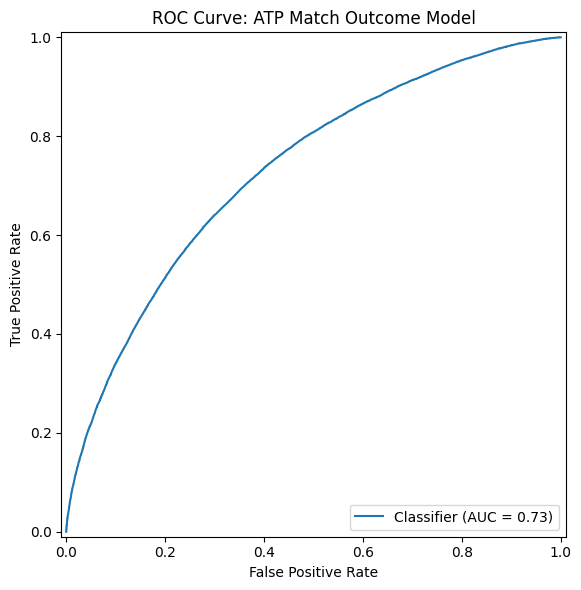

Saved plot to: /Users/dylandietrich/Documents/New project/images/pipeline_check_roc.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title("ROC Curve: ATP Match Outcome Model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

plot_path = IMAGES_DIR / "pipeline_check_roc.png"
fig.savefig(plot_path, dpi=300, bbox_inches="tight")
print("Saved plot to:", plot_path)

## Results

The pipeline successfully loaded the relational tables into DuckDB, prepared a modeling dataset with SQL, and trained a binary classification model to predict whether a player wins a match. The model achieved an accuracy of about 0.67 and an ROC AUC of about 0.73 on the held-out test set, which indicates meaningful predictive signal above random guessing.

## Visualization Rationale

I used an ROC curve because the task is binary classification and the model outputs probabilities. The ROC curve is useful because it shows how well the model separates wins from losses across classification thresholds, which makes it more informative than accuracy alone.

In [ ]:
con.close()